# EDA + Regresión Logística — Bank Marketing Campaign

**Objetivo:** Predecir si un cliente contratará un depósito a largo plazo (`y = yes/no`).

**Tipo de problema:** Clasificación binaria → Regresión Logística.


# Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre bank-marketing-campaign-data.csv, y puedes cargarlo en el código directamente desde el siguiente enlace:

https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

age. Edad del cliente (numérico)
job. Tipo de trabajo (categórico)
marital. Estado civil (categórico)
education. Nivel de educación (categórico)
default. ¿Tiene crédito actualmente? (categórico)
housing. ¿Tiene un préstamo de vivienda? (categórico)
loan. ¿Tiene un préstamo personal? (categórico)
contact. Tipo de comunicación de contacto (categórico)
month. Último mes en el que se le ha contactado (categórico)
day_of_week. Último día en el que se le ha contactado (categórico)
duration. Duración del contacto previo en segundos (numérico)
campaign. Número de contactos realizados durante esta campaña al cliente (numérico)
pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)
poutcome. Resultado de la campaña de marketing anterior (categórico)
emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)
cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)
cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)
euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)
nr.employed. Número de empleados. Indicador trimestral (numérico)
y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

# Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

# Paso 3: Construye un modelo de regresión logística
No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.

# Paso 4: Optimiza el modelo anterior
Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.

In [32]:
#importamos librerias

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 
import scipy.stats as stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------

# Paso 1 


In [33]:
df = pd.read_csv("../data/raw/bank-marketing-campaign-data.csv", sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [34]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [35]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [36]:
df.shape

(41188, 21)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [38]:
df.dtypes.value_counts()

str        11
int64       5
float64     5
Name: count, dtype: int64

- Tener tantas variables categoricas significa que el conjunto de datos es rico en información cualitativa pero presenta desafíos técnicos significativos para el análisis estadístico y el aprendizaje automático

In [39]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [40]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

In [41]:
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [42]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


- Vemos que la columna "duration" tiene un valor atipico de 4918 

In [43]:
variables_numericas = df.columns
variables_categoricas = df.select_dtypes(include=['object']).columns
print(variables_categoricas)
print(variables_numericas)


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')


/tmp/ipykernel_1446/3135638741.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df.select_dtypes(include=['object']).columns


Podemos observar que este data set no tiene ningun valor nulo.

In [44]:
df.y.value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

Text(0, 0.5, 'Frecuencia')

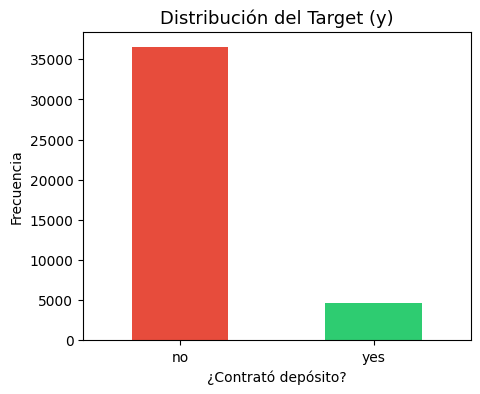

In [45]:
fig, ax = plt.subplots(figsize=(5,4))
df.y.value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], rot=0)
ax.set_title('Distribución del Target (y)', fontsize=13)
ax.set_xlabel('¿Contrató depósito?')
ax.set_ylabel('Frecuencia')

- Segun los datos de quien contrato el deposito vemos que actualmente la mayoria no lo ha contratado 


# Tratamiento de valores nulos o unknown

In [46]:
# TRATAMIENTO DE UNKNOWN EN LAS VARIABLES CATEGORICAS 
(df == 'unknown').sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [47]:
cols_con_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

for col in cols_con_unknown:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        moda = df[col].mode()[0]
        df[col] = df[col].replace('unknown', moda)
        print(f'  {col}: {n} unknowns reemplazados por "{moda}"')

  job: 330 unknowns reemplazados por "admin."
  marital: 80 unknowns reemplazados por "married"
  education: 1731 unknowns reemplazados por "university.degree"
  default: 8597 unknowns reemplazados por "no"
  housing: 990 unknowns reemplazados por "yes"
  loan: 990 unknowns reemplazados por "no"


In [48]:
df['job'].value_counts() #confirmo que no hay mas datos unknown

job
admin.           10752
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Name: count, dtype: int64

# Analisis de datos univariable 

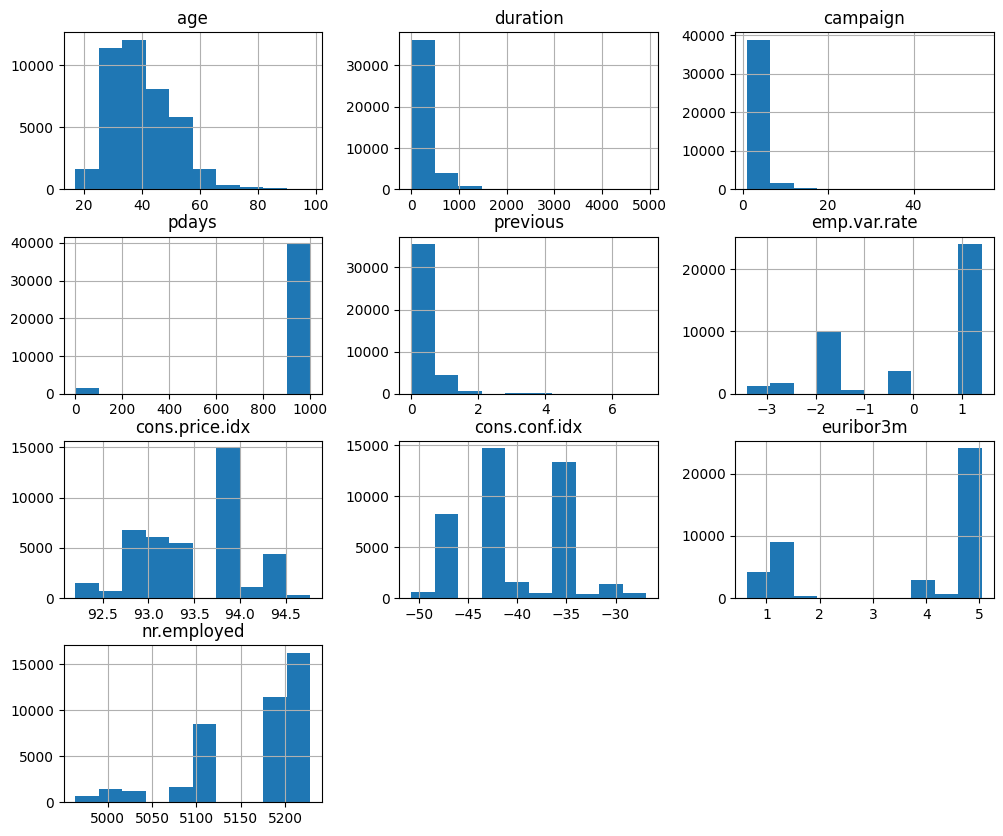

In [49]:
df.hist(figsize=(12,10))
plt.show()

Vemos que los datos no siguen una distribucion normal 

In [50]:
columnas_numericas = df.select_dtypes(include=[np.number])
columnas_numericas


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6


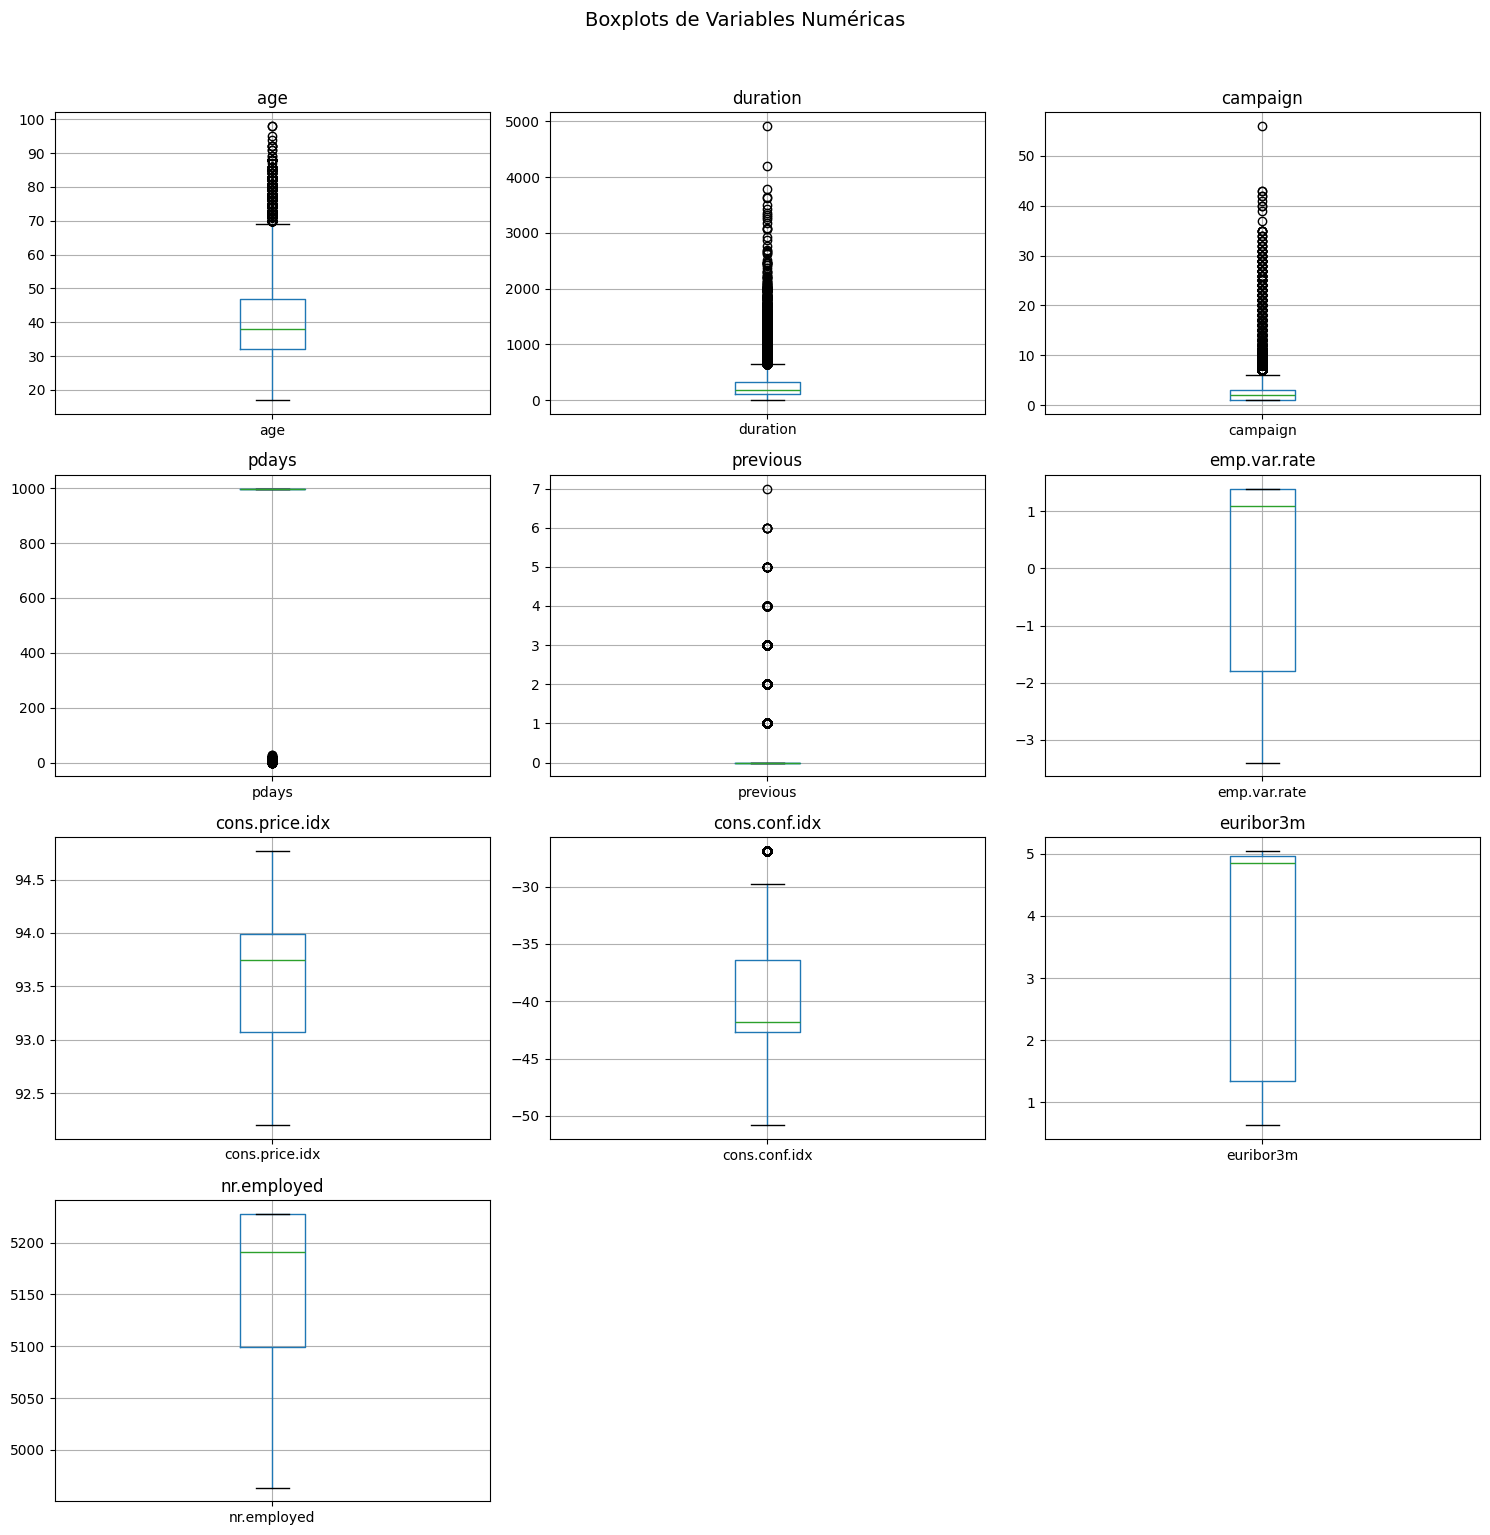

In [51]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(columnas_numericas):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots de Variables Numéricas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

- Revisando esta grafica podriamos tomar ciertas decisiones a la hora de visualizar la variable pdays y previous. 

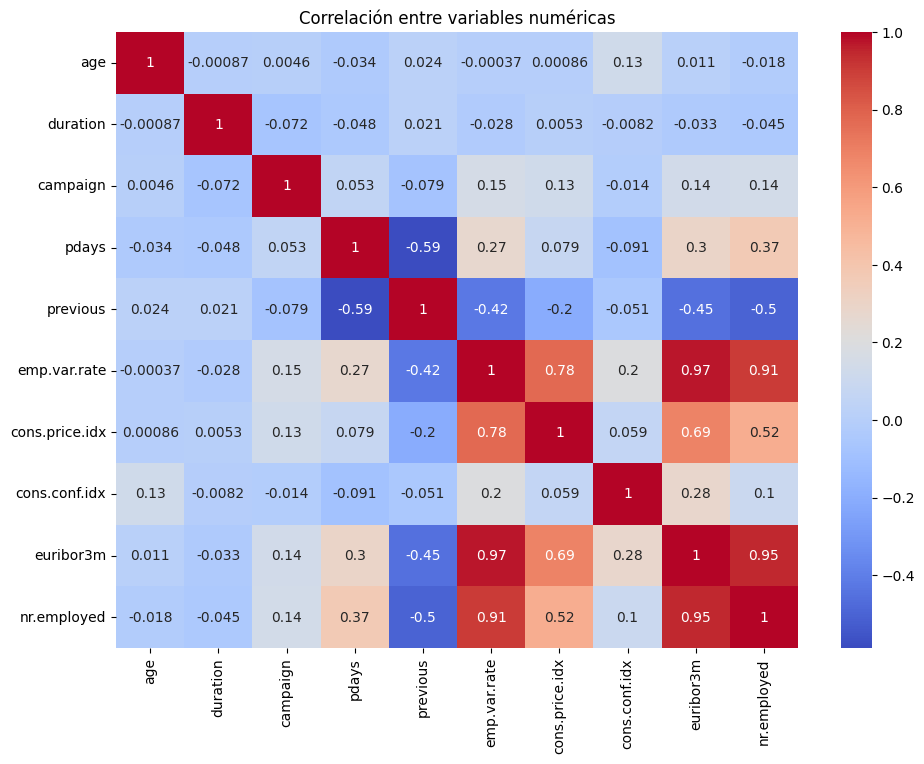

In [52]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

- emp.var.rate, euribor3m y nr.employed están altamente correlacionadas
esto es multicolinealidad — a considerar en la regresión logística

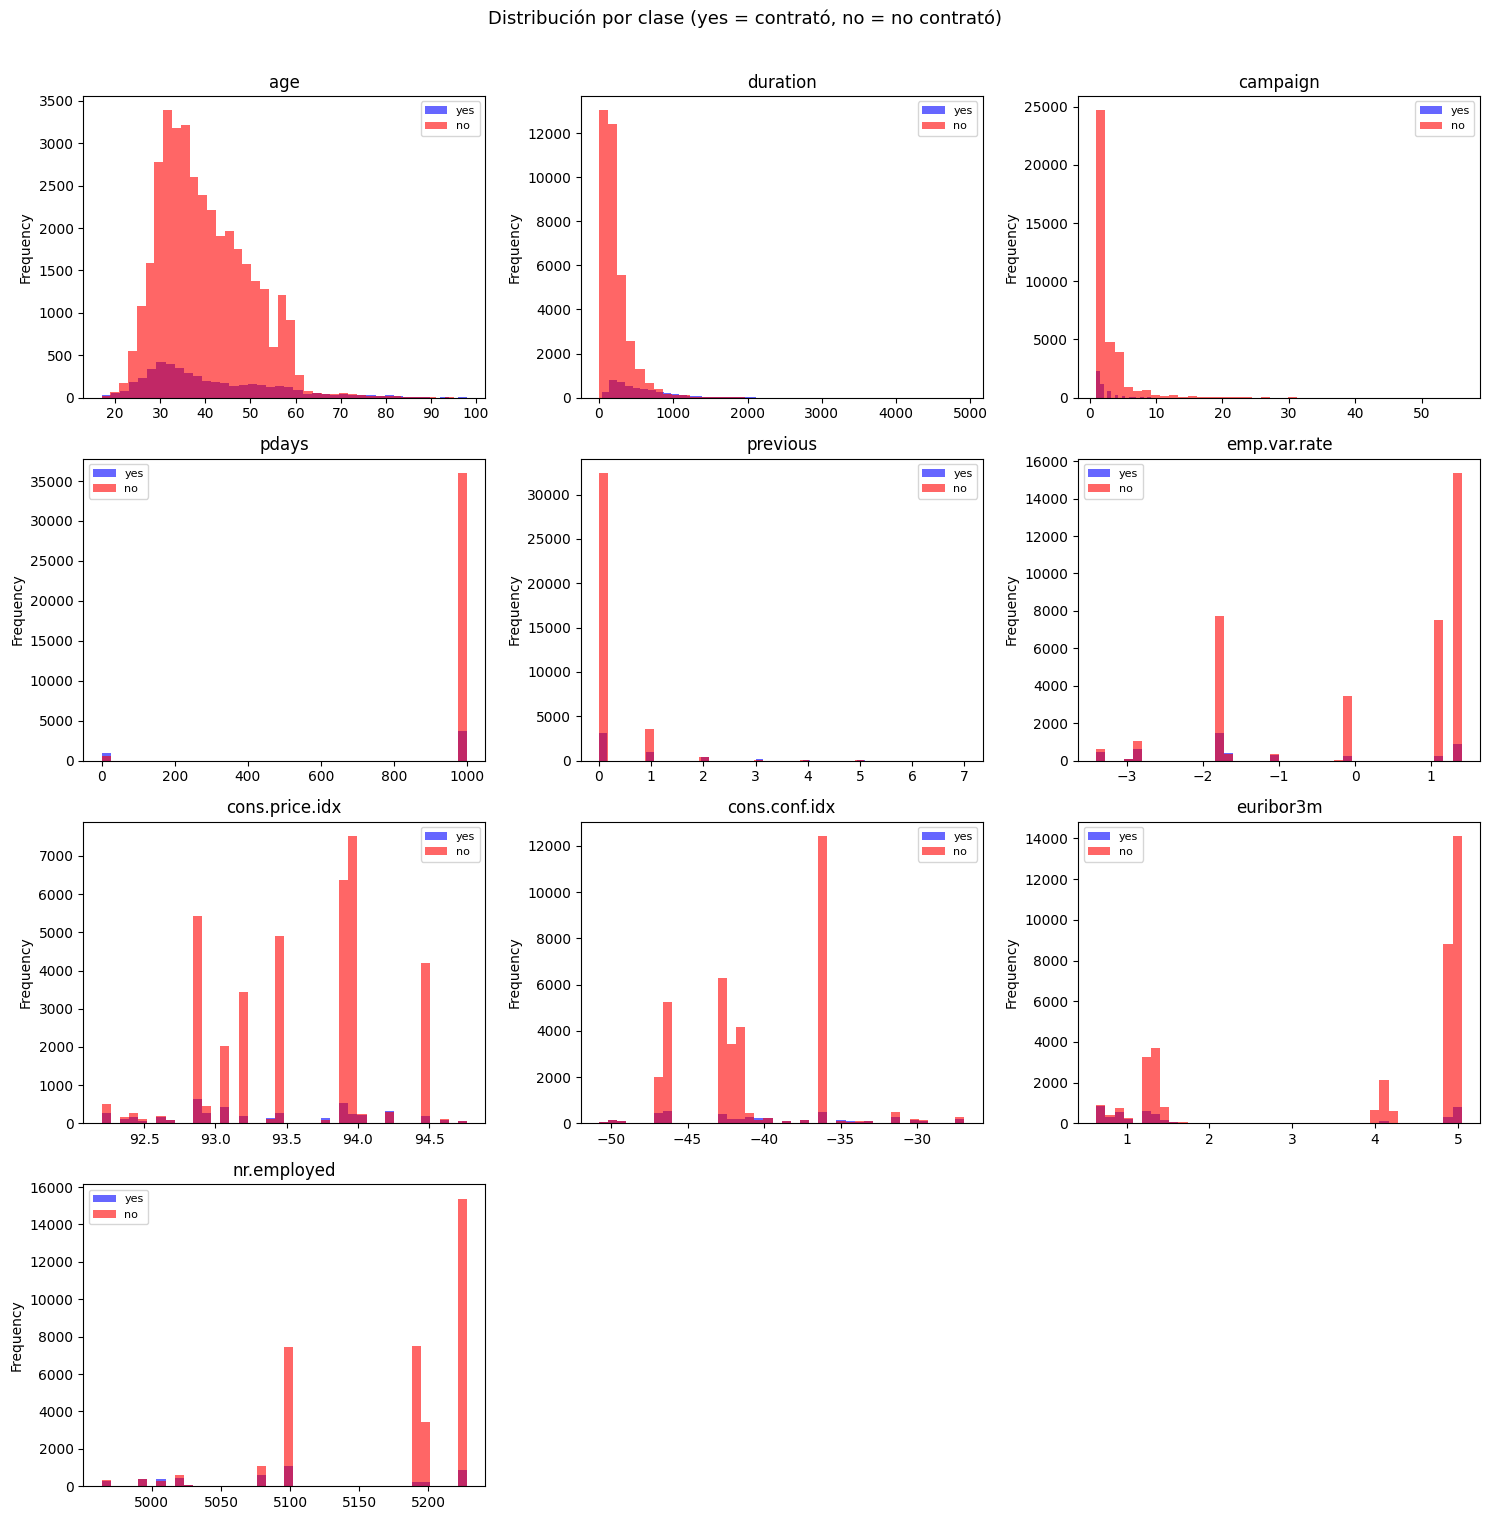

In [53]:
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas[:9]):
    df[df['y']=='yes'][col].plot(kind='hist', bins=40, ax=axes[i], alpha=0.6, label='yes', color='blue')
    df[df['y']=='no'][col].plot(kind='hist', bins=40, ax=axes[i], alpha=0.6, label='no', color='red')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución por clase (yes = contrató, no = no contrató)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Transformación de datos 


In [54]:
variables_categoricas

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

In [55]:
df['default'].value_counts()

default
no     41185
yes        3
Name: count, dtype: int64

In [56]:
data = df.copy()
data = data.drop("duration", axis=1)

Eliminamos la columa duration porque es un data leak 

In [57]:
data = pd.get_dummies(data, drop_first=True)
data = data.rename(columns={"y_yes": "y"}) # cambiamos el nombre de la columna para mantener el y 
pd.set_option('display.max_columns', None)
data


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True
41184,46,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
41185,56,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
41186,44,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True


# Hacemos el Split 

In [58]:
X = data.drop("y", axis= 1)
y = data["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
25611,49,4,999,0,-0.1,93.200,-42.0,4.120,5195.8,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False
26010,37,2,999,1,-0.1,93.200,-42.0,4.120,5195.8,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
40194,78,1,999,0,-1.7,94.215,-40.3,0.870,4991.6,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False
297,36,2,999,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
36344,59,2,999,0,-2.9,92.963,-40.8,1.262,5076.2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40205,28,1,999,0,-1.7,94.215,-40.3,0.876,4991.6,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False
27316,52,1,999,1,-0.1,93.200,-42.0,4.021,5195.8,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
14392,54,4,999,0,1.4,93.918,-42.7,4.962,5228.1,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False
7494,29,1,999,0,1.1,93.994,-36.4,4.864,5191.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False


# Hacemos escalado

In [59]:
# Escalado: OBLIGATORIO para Regresión Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)   

# Guardamos datos 


In [60]:
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('./data/processed/X_train_bank.csv', index=False)
pd.DataFrame(X_test_scaled,  columns=X.columns).to_csv('./data/processed/X_test_bank.csv',  index=False)
y_train.to_csv('./data/processed/y_train_bank.csv', index=False, header=True)
y_test.to_csv( './data/processed/y_test_bank.csv',  index=False, header=True)

# Modelo de regresión logistica 

In [61]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

Reporte de Clasificación:
               precision    recall  f1-score   support

       False       0.91      0.99      0.95      7310
        True       0.69      0.22      0.34       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



Aunque el modelo muestra una accuracy del 90%, su rendimiento real es pobre para la clase True, ya que solo detecta el 22% de los casos positivos. Esto indica un fuerte desbalanceo y que la regresión logística está sesgada hacia la clase mayoritaria. Para mejorar, habría que aplicar técnicas de rebalanceo o ajustar el umbral de decisión.


# Mejoramos el modelo 


In [ ]:
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_proba_balanced = model_balanced.predict_proba(X_test_scaled)
print("Reporte de Clasificación:\n", classification_report(y_test, y_pred_balanced))

Con la mejora del modelo usando class_weight="balanced" hemos visto que el recall ha aumentado a 0.64 por lo que el modelo ahora detecta mucho mejor la clase True, pero a costa de perder mucha precisión en False y bajar la accuracy global, pero nos interesa saber porque la clase true es importante. 